In [156]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

In [157]:
# https://www.kaggle.com/datasets/mabubakrsiddiq/student-exam-performance
data = pd.read_csv("student_performance_interactions.csv")
data.head()

,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet


In [158]:
print(data.columns)

Index(['student_id', 'final_score', 'grade', 'pass_fail', 'previous_score',
       'math_prev_score', 'science_prev_score', 'language_prev_score',
       'daily_study_hours', 'attendance_percentage',
       'homework_completion_rate', 'sleep_hours', 'screen_time_hours',
       'physical_activity_minutes', 'motivation_score', 'exam_anxiety_score',
       'parent_education_level', 'study_environment'],
      dtype='str')


In [159]:
data.describe()

,final_score,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.935159,0.930000,66.964110,67.458590,67.033210,66.906063,2.984155,73.275703,79.755579,6.964696,3.475139,75.914922,6.973272,3.167954
std,14.376419,0.255275,16.067555,16.593689,17.105514,16.705229,1.158047,9.533937,12.360754,0.684015,1.395155,25.777316,1.780761,1.806371
min,37.364699,0.000000,40.254761,30.235250,25.752553,27.176600,1.003774,47.445725,51.604853,4.500750,1.000264,30.220913,4.000946,1.000000
25%,60.079082,1.000000,52.978530,53.098000,52.509398,53.562773,1.985539,66.256237,69.964528,6.518039,2.318330,54.076377,5.427378,1.369204
50%,70.673531,1.000000,67.324406,67.561105,66.133873,66.693546,2.934717,73.328172,79.393715,6.976139,3.472257,75.819676,6.910094,3.098631
75%,81.830057,1.000000,80.937577,81.380928,81.319085,80.269633,3.971015,80.230732,89.592788,7.413489,4.618956,98.505332,8.577936,4.600374
max,100.000000,1.000000,94.984472,104.984169,107.432492,107.561521,4.997401,99.111497,110.485203,9.353503,5.984953,119.970588,9.992500,8.535907


In [160]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   str    
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   str    
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13  physical_activity_minutes  1000 non-null   float64
 14  moti

In [161]:
data = data.drop(['student_id', 'grade','pass_fail', 'parent_education_level', 'study_environment'], axis=1)

In [162]:
data.head(5)

,final_score,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score
0,60.137241,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103
1,99.021977,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358
2,70.522955,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662
3,63.448537,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474
4,66.483019,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852


In [163]:
y = data['final_score'].values
X = data.drop('final_score', axis=1).values

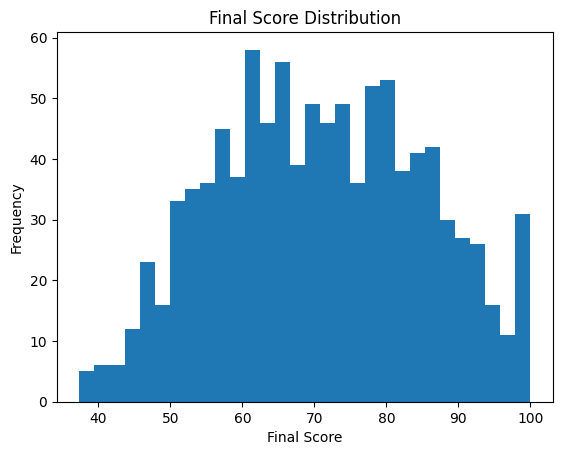

In [164]:
plt.figure()
plt.hist(y, bins=30)
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.title("Final Score Distribution")
plt.show()

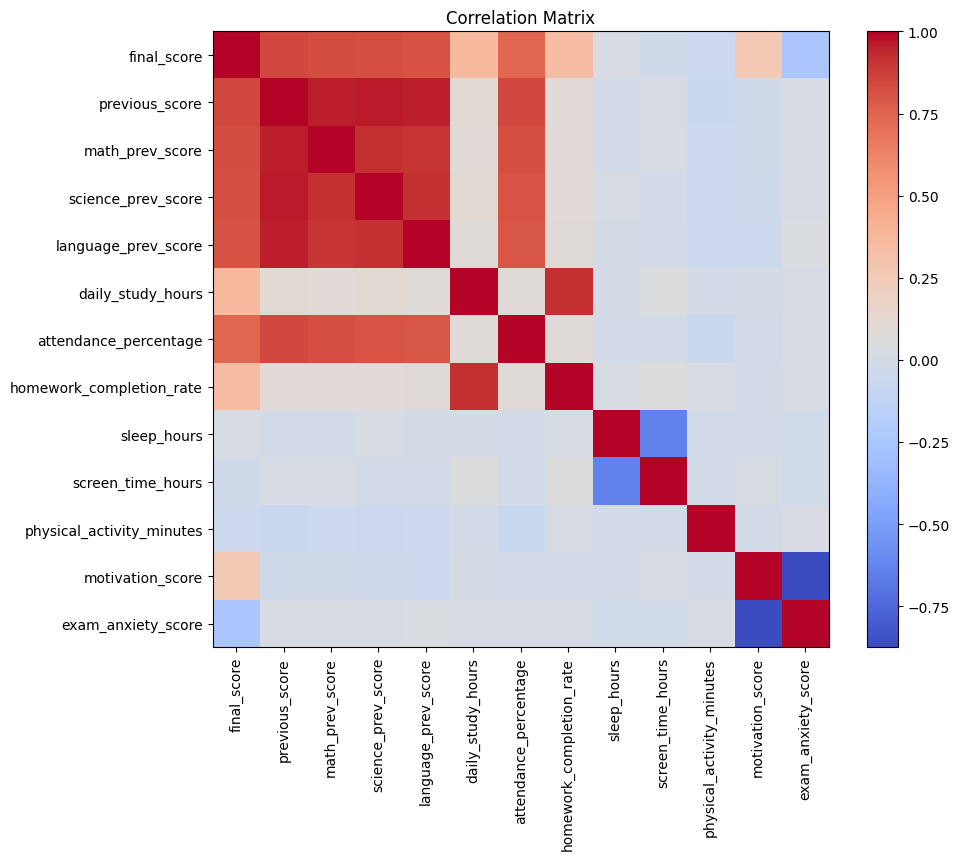

In [165]:
plt.figure(figsize=(10,8))

corr = data.corr()

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

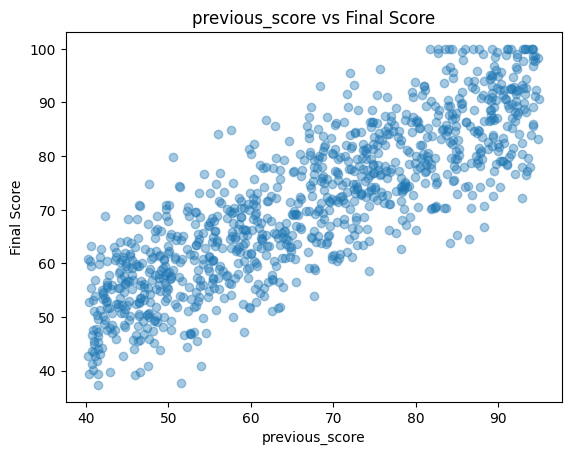

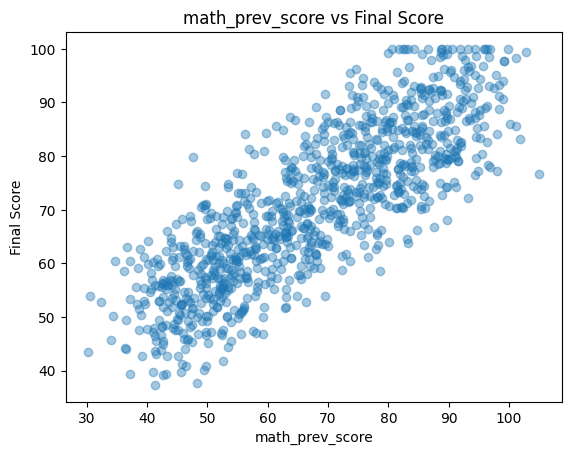

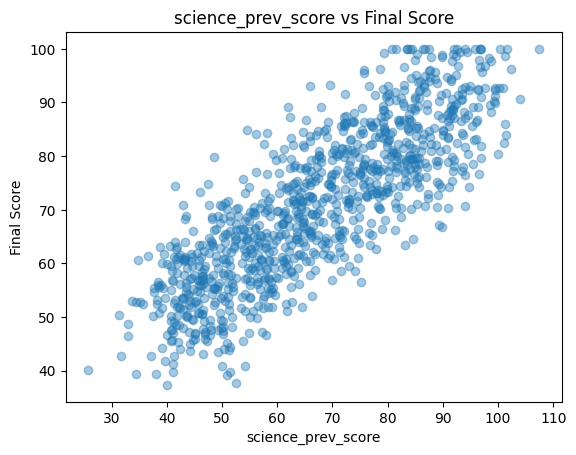

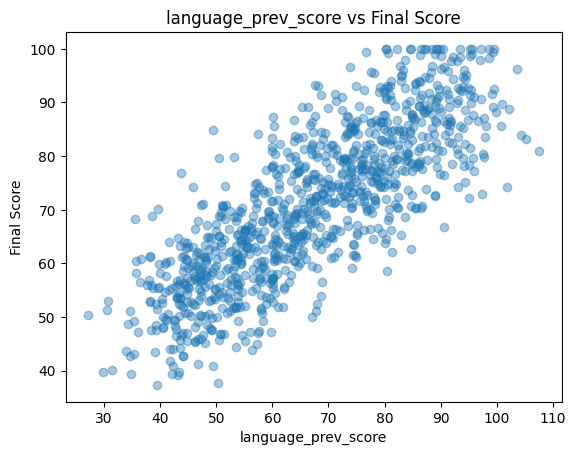

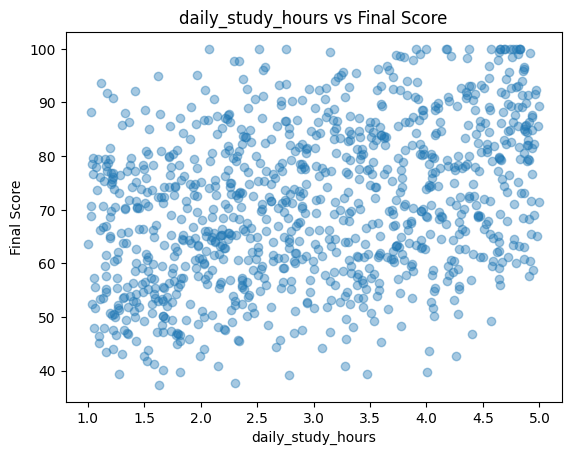

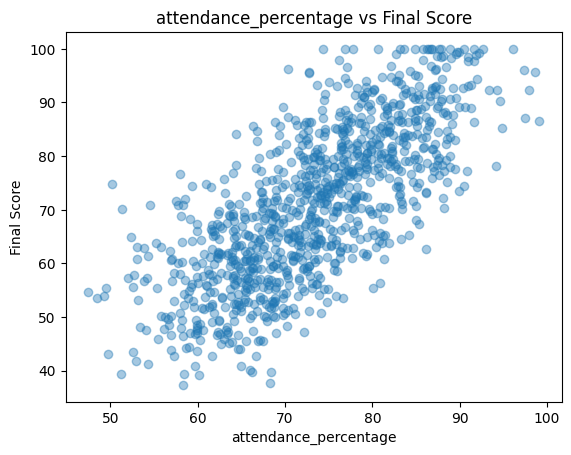

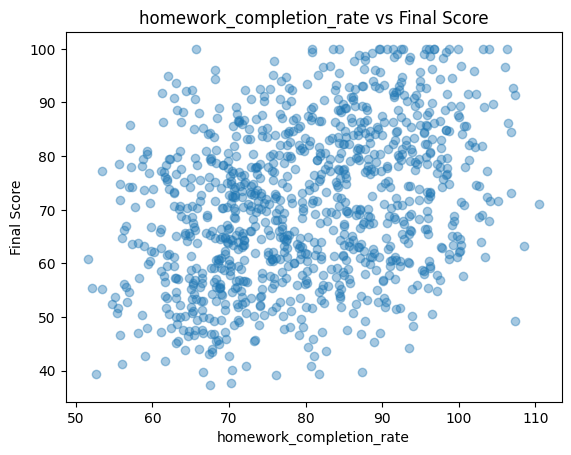

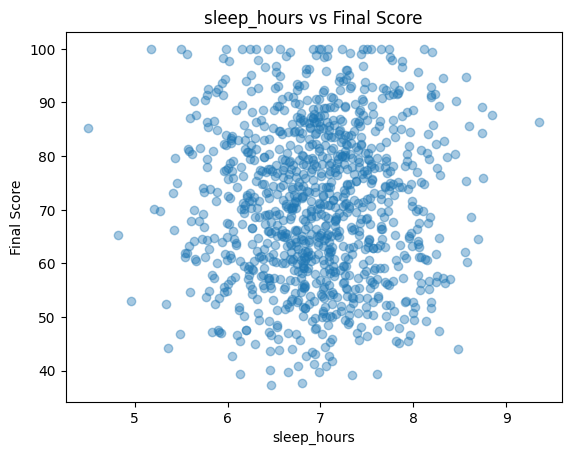

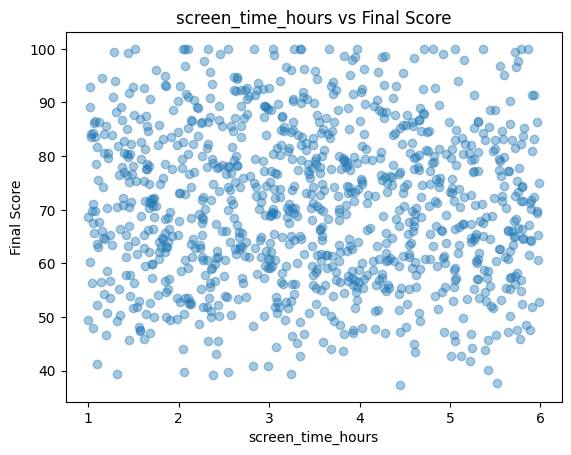

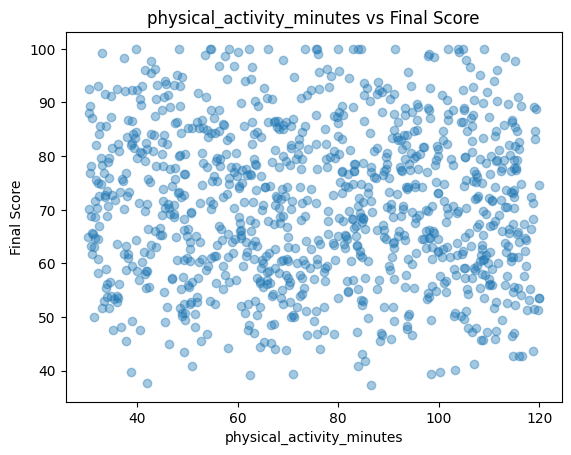

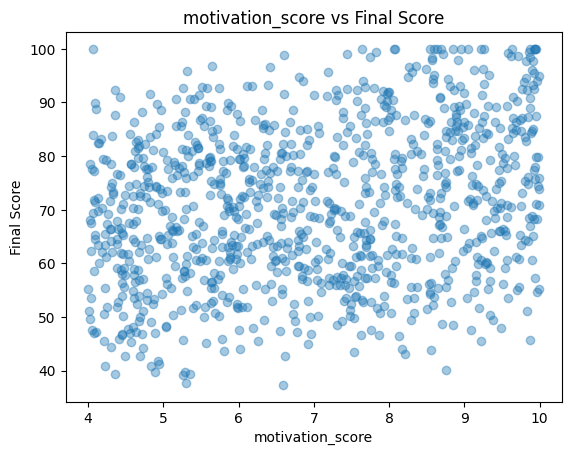

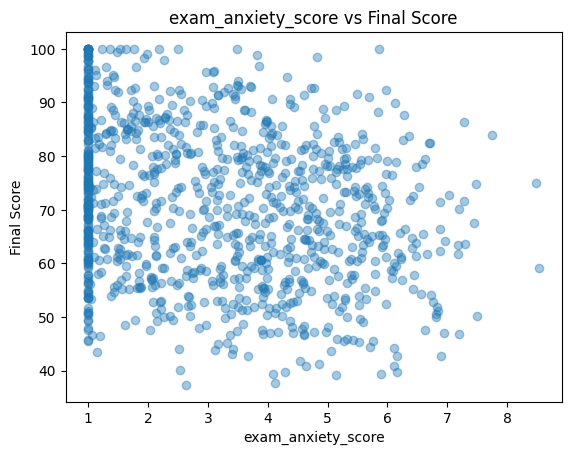

In [166]:
feature_names = data.drop('final_score', axis=1).columns.tolist()
for name in feature_names:
    plt.figure()
    plt.scatter(data[name], y, alpha=0.4)
    plt.xlabel(name)
    plt.ylabel("Final Score")
    plt.title(f"{name} vs Final Score")
    plt.show()

In [167]:
def train_test_split(X, y, test_size = 0.2, seed = 42):
    np.random.seed(seed)
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = idx[:split], idx[split:]
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, seed=42)

In [168]:
def standardize_fit(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0) + 1e-12
    return mu, sigma

def standardize_transform(X, mu, sigma):
    return (X - mu) / sigma

mu, sigma = standardize_fit(X_train)

X_train_mu = standardize_transform(X_train, mu, sigma)
X_test_mu = standardize_transform(X_test, mu, sigma)

In [169]:
def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def rmse(y, y_pred):
    return np.sqrt(mse(y, y_pred))

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-12))

In [170]:
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

In [171]:
def linear_regression_gd(X, y, lr=0.05, epochs=2000, tol=1e-6):
    Xb = add_bias(X)
    n, d = Xb.shape
    w = np.zeros(d)
    loss_history = []
    prev_loss = float('inf')
    start = time.time()
    for epoch in range(epochs):
        y_pred = Xb @ w
        error = y_pred - y
        grad = (2/n) * (Xb.T @ error)
        w -= lr * grad
        loss = mse(y, y_pred)
        loss_history.append(loss)
        if abs(prev_loss - loss) < tol:
            break
        prev_loss = loss
    train_time = time.time() - start
    return w, loss_history, epoch+1, train_time

In [172]:
w, loss_history, n_epochs, train_time = linear_regression_gd(X_train_mu, y_train, lr=0.05)

print("Training Time:", round(train_time, 4), "seconds")
print("Epochs:", n_epochs)

Training Time: 0.0125 seconds
Epochs: 1184


In [173]:
def predict(X, w):
    Xb = add_bias(X)
    return Xb @ w


y_train_pred = predict(X_train_mu, w)
y_test_pred  = predict(X_test_mu,  w)

In [174]:
print("====== TRAIN ======")
print("MSE :", mse(y_train, y_train_pred))
print("RMSE:", rmse(y_train, y_train_pred))
print("MAE :", mae(y_train, y_train_pred))
print("R2  :", r2_score(y_train, y_train_pred))

print("\n====== TEST ======")
print("MSE :", mse(y_test, y_test_pred))
print("RMSE:", rmse(y_test, y_test_pred))
print("MAE :", mae(y_test, y_test_pred))
print("R2  :", r2_score(y_test, y_test_pred))

====== TRAIN ======
MSE : 23.958702453178077
RMSE: 4.894762757598991
MAE : 3.9138209993890074
R2  : 0.8835142629717484

====== TEST ======
MSE : 24.514157700439377
RMSE: 4.951177405470276
MAE : 3.999735636005393
R2  : 0.8830730986658103


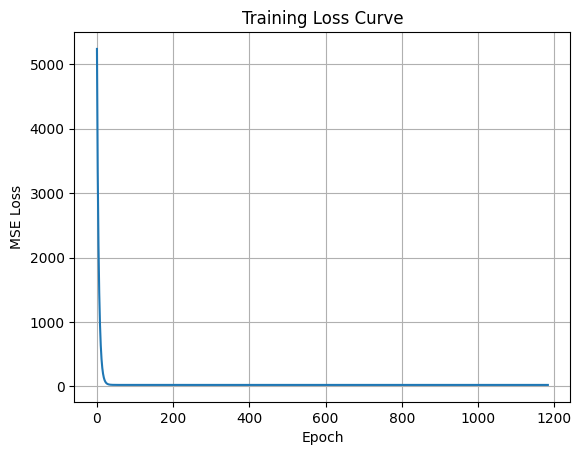

In [175]:
plt.figure()

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")

plt.grid(True)
plt.show()

In [176]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()

Xtr_std = scaler.fit_transform(Xtr)
Xte_std = scaler.transform(Xte)

# Train
start = time.time()

model = LinearRegression()
model.fit(Xtr_std, ytr)

sk_time = time.time() - start

# Predict
yte_pred = model.predict(Xte_std)

# Evaluate
print("\n====== SKLEARN ======")
print("Training time:", round(sk_time,4))
print("MSE :", mean_squared_error(yte, yte_pred))
print("RMSE:", np.sqrt(mean_squared_error(yte, yte_pred)))
print("MAE :", mean_absolute_error(yte, yte_pred))
print("R2  :", r2_score(yte, yte_pred))


====== SKLEARN ======
Training time: 0.0097
MSE : 20.38995275579919
RMSE: 4.515523530643948
MAE : 3.578658059324982
R2  : 0.8985921084392683
